In [17]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

from scipy.io import arff





In [18]:
data, meta = arff.loadarff("dataset.arff")

df = pd.DataFrame(data)

In [19]:
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [20]:
df['Class'].unique()

array([0., 1.])

In [21]:
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = df[col].apply(
        lambda x: x.decode("utf-8") if isinstance(x, bytes) else x
    )

print(df.dtypes)

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class     float64
dtype: object


In [22]:
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (283726, 31)


In [23]:
target_column = "Class"

print(df[target_column].value_counts())
print(df[target_column].value_counts(normalize=True))

Class
0.0    283253
1.0       473
Name: count, dtype: int64
Class
0.0    0.998333
1.0    0.001667
Name: proportion, dtype: float64


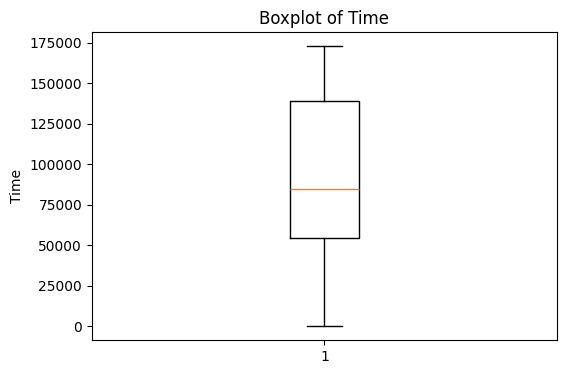

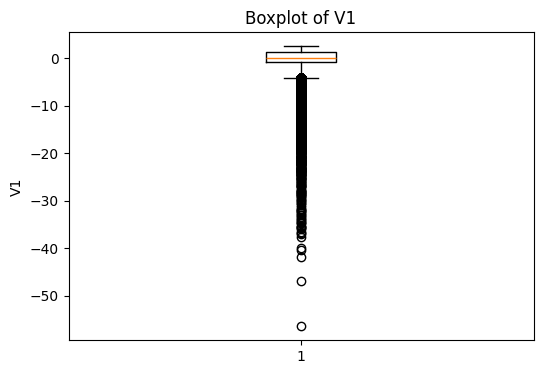

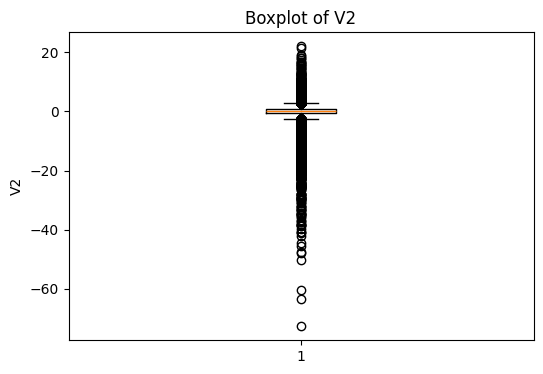

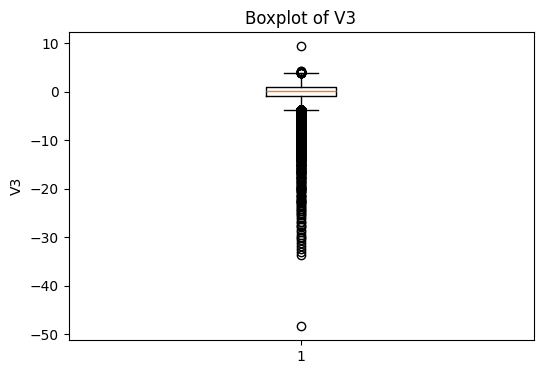

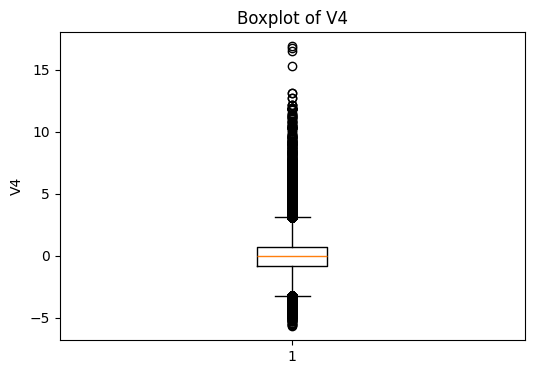

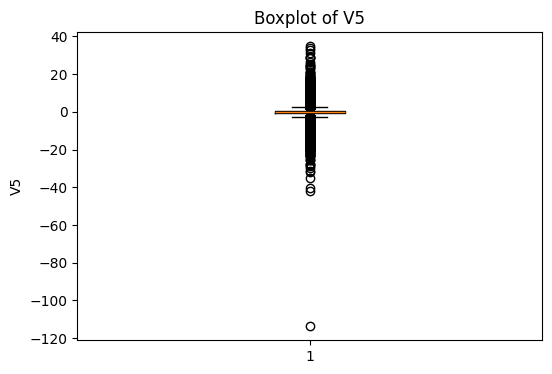

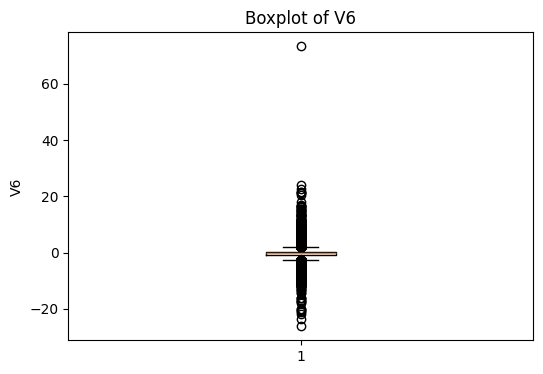

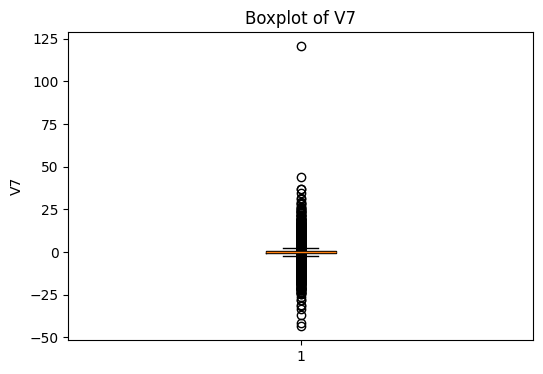

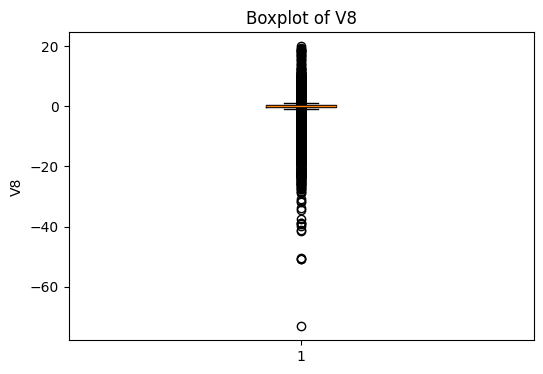

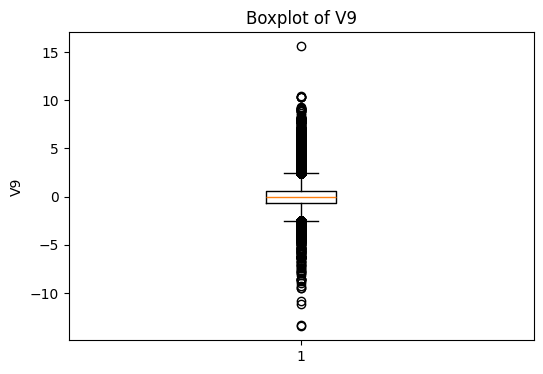

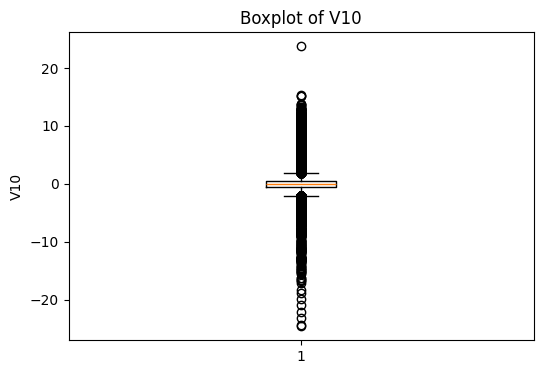

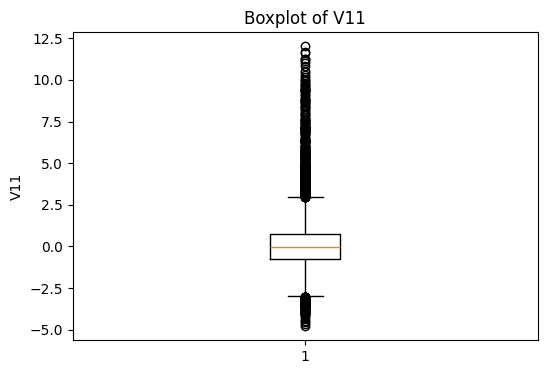

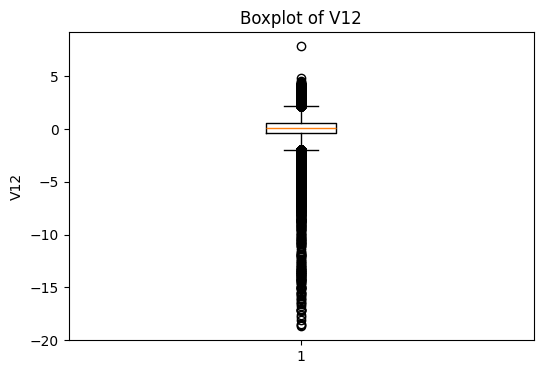

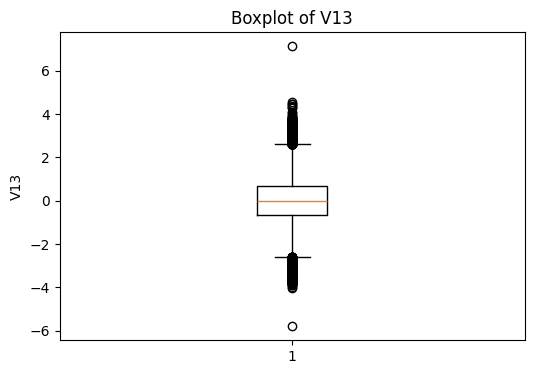

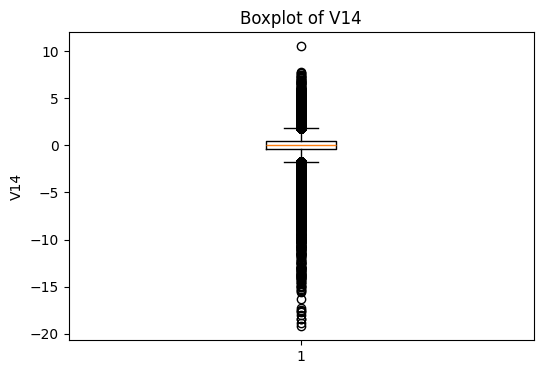

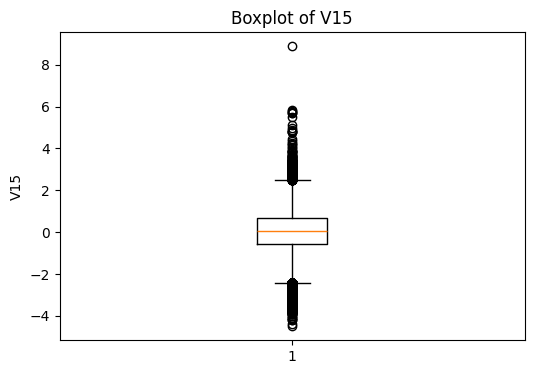

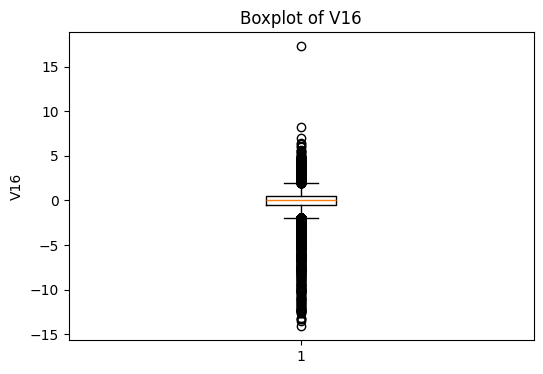

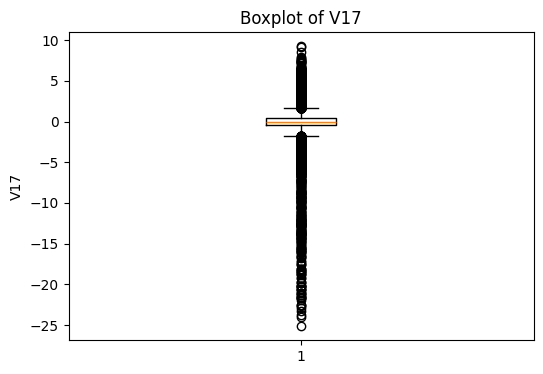

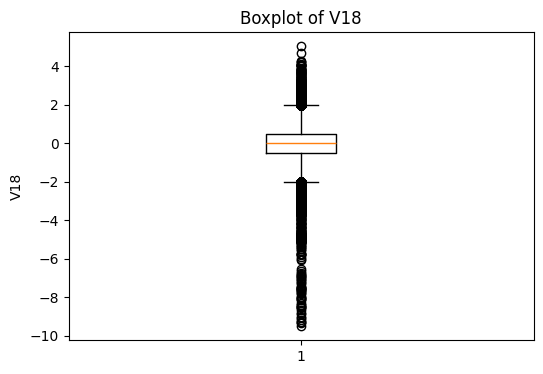

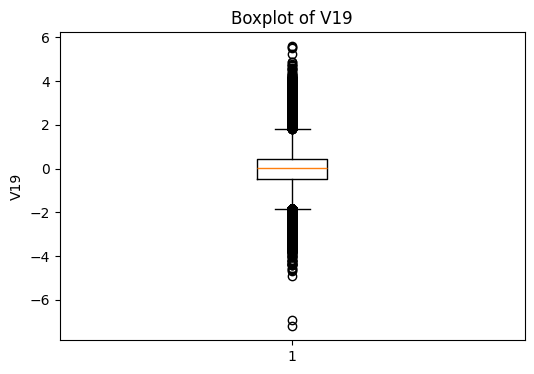

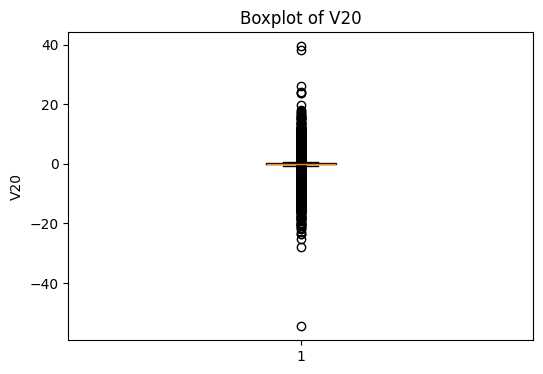

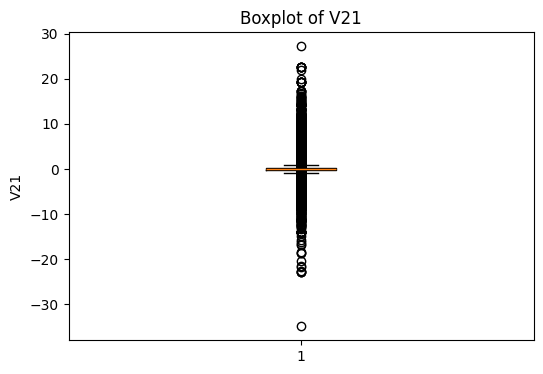

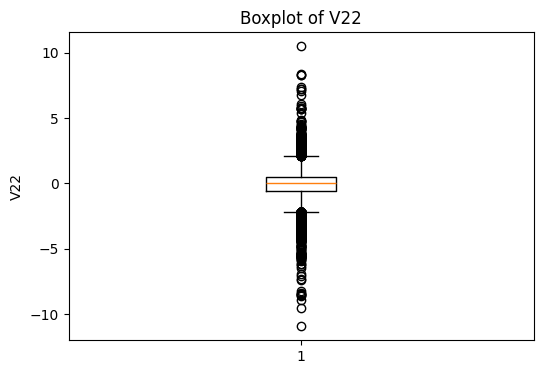

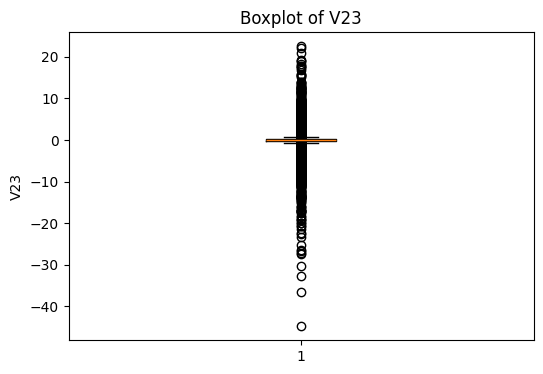

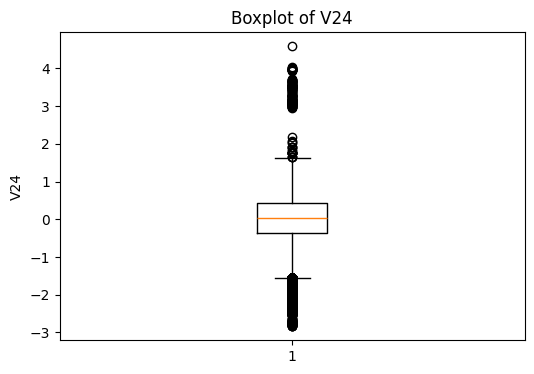

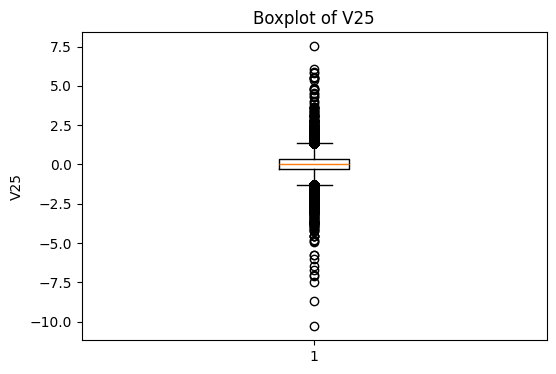

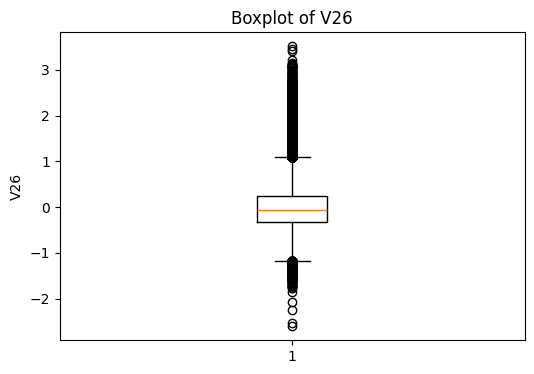

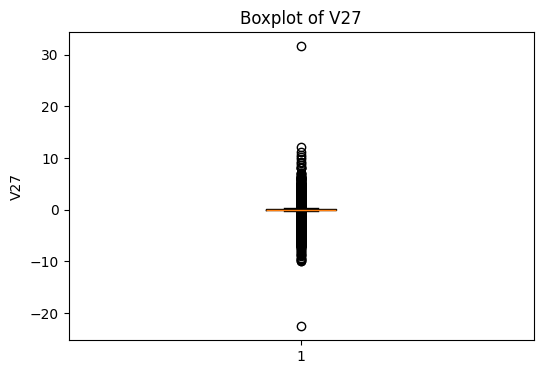

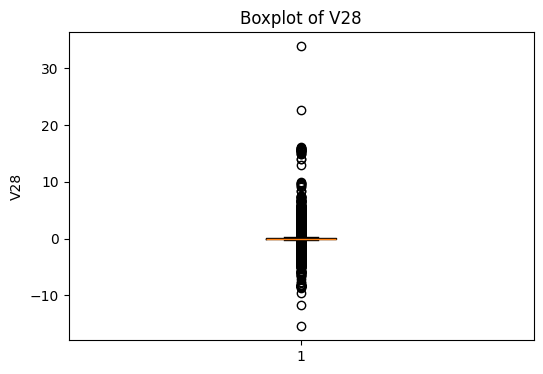

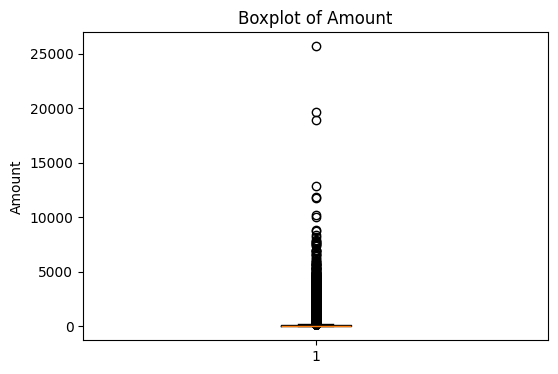

In [24]:
for col in numeric_cols:

    plt.figure(figsize=(6, 4))

    plt.boxplot(df[col].dropna())

    plt.ylabel(col)
    plt.title(f"Boxplot of {col}")

    plt.show()

Class
0.0    283253
1.0       473
Name: count, dtype: int64


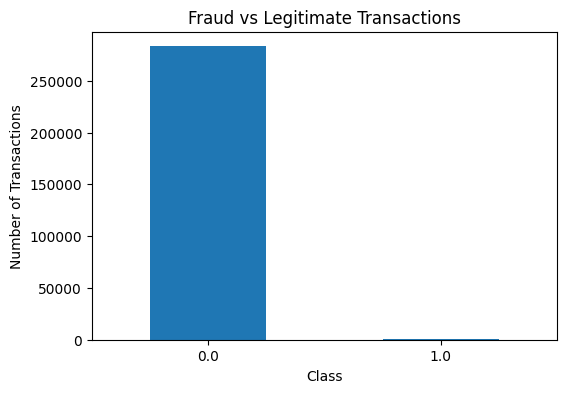

In [25]:
class_counts = df[target_column].value_counts().sort_index()

print(class_counts)

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.title("Fraud vs Legitimate Transactions")
plt.xticks(rotation=0)
plt.show()

In [26]:
class_percentage = (
    df[target_column]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

print(class_percentage)

Class
0.0    99.83329
1.0     0.16671
Name: proportion, dtype: float64


In [27]:
class_percentage = (
    df[target_column]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

print(class_percentage)

Class
0.0    99.83329
1.0     0.16671
Name: proportion, dtype: float64


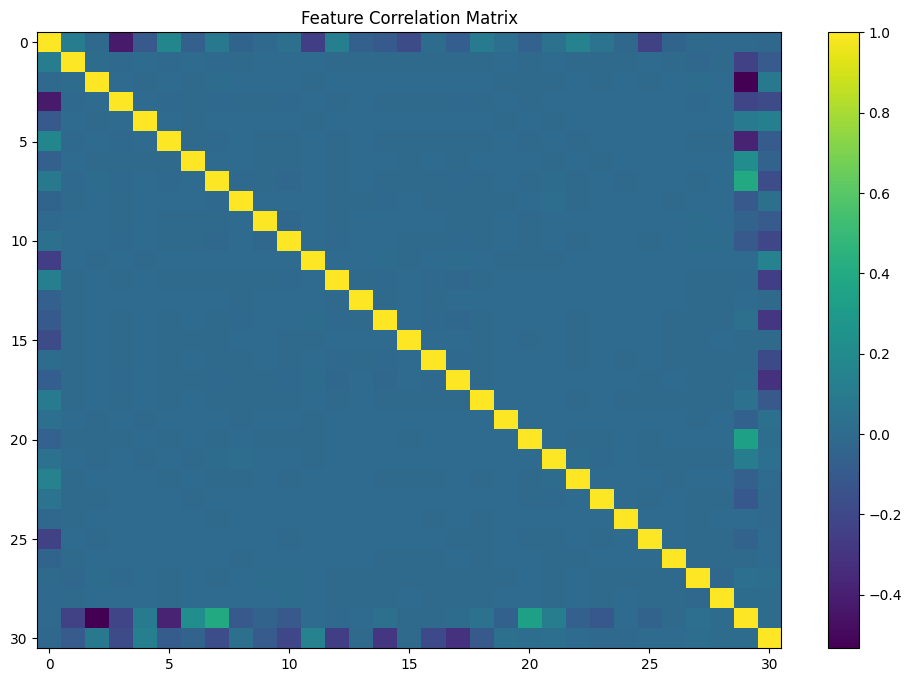

In [28]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

plt.figure(figsize=(12, 8))
plt.imshow(correlation, aspect="auto")
plt.colorbar()

plt.title("Feature Correlation Matrix")
plt.show()

In [29]:
X = df.drop(columns=[target_column])
y = df[target_column]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (283726, 30)
y Shape: (283726,)


In [30]:
numeric_cols = X.select_dtypes(
    include=["int64", "int32", "float64", "float32"]
).columns.tolist()

categorical_cols = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical Features:", len(numeric_cols))
print("Categorical Features:", len(categorical_cols))

print("\nNumerical Columns:")
print(numeric_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Features: 30
Categorical Features: 0

Numerical Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']

Categorical Columns:
[]


In [31]:
df.to_csv('eda.csv',index=False)